# Optimize FFT Grid for Smooth K-Space

**Goal:** The FFT+Fraunhofer approach is already correct (RMSE=0.028), but has noisy k-space due to FFT discretization.

**Strategy:** Optimize grid parameters to get smoother |FFT|² in k-space.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import j1

from monte_carlo import metrics

sns.set_theme(style="whitegrid", font_scale=1.2)

## Current FFT Grid Analysis

In [2]:
# Parameters
wavelength = 0.6328  # microns
focal_length = 10.0  # mm
NA = 0.1
n_medium = 1.0
fft_size = 2048

k = 2 * np.pi * n_medium / wavelength
k_max = k * (NA / n_medium)
aperture_radius = (NA * focal_length) / n_medium

# Current grid calculation (from angular_spectrum.py)
desired_k_points = 50
L_from_k = desired_k_points * 2 * np.pi / k_max
L_from_aperture = 20 * aperture_radius
L = max(L_from_k, L_from_aperture)
dx = L / fft_size

print("CURRENT FFT GRID:")
print(f"  FFT size: {fft_size}")
print(f"  Domain size L: {L:.2f} mm")
print(f"  Pixel spacing dx: {dx:.4f} mm = {dx*1000:.1f} μm")
print(f"  Aperture radius R: {aperture_radius:.4f} mm")
print(f"  Pixels across aperture diameter: {2 * aperture_radius / dx:.1f}")
print(f"\n  K-space resolution dk: {2*np.pi/L:.4f} rad/mm = {2*np.pi/(L*1000):.6f} rad/μm")
print(f"  k_max: {k_max:.4f} rad/μm")
print(f"  Points within k_max: {k_max / (2*np.pi/(L*1000)):.1f}")

CURRENT FFT GRID:
  FFT size: 2048
  Domain size L: 316.40 mm
  Pixel spacing dx: 0.1545 mm = 154.5 μm
  Aperture radius R: 1.0000 mm
  Pixels across aperture diameter: 12.9

  K-space resolution dk: 0.0199 rad/mm = 0.000020 rad/μm
  k_max: 0.9929 rad/μm
  Points within k_max: 50000.0


## Test Different Grid Configurations

In [3]:
def compute_fft_spectrum(fft_size, L, aperture_radius, k_max):
    """Compute angular spectrum FFT and measure k-space quality."""
    dx = L / fft_size
    
    # Create aperture
    x = np.linspace(-L/2, L/2, fft_size)
    y = np.linspace(-L/2, L/2, fft_size)
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)
    aperture = (R <= aperture_radius).astype(float)
    
    # FFT
    fft_aperture = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(aperture)))
    angular_spectrum = np.abs(fft_aperture)**2
    
    # K-space grid
    kx_1d = np.fft.fftshift(np.fft.fftfreq(fft_size, dx)) * 2 * np.pi
    ky_1d = np.fft.fftshift(np.fft.fftfreq(fft_size, dx)) * 2 * np.pi
    kx_grid, ky_grid = np.meshgrid(kx_1d, ky_1d)
    
    # Radial k-space profile
    k_rho_grid = np.sqrt(kx_grid**2 + ky_grid**2)
    
    # Filter to valid k-space
    valid_mask = k_rho_grid <= k_max
    k_rho_valid = k_rho_grid[valid_mask]
    intensity_valid = angular_spectrum[valid_mask]
    
    # Bin by k_rho
    k_bins = np.linspace(0, k_max, 100)
    k_centers = (k_bins[:-1] + k_bins[1:]) / 2
    
    # Compute radial average
    k_hist = []
    for i in range(len(k_bins)-1):
        mask = (k_rho_valid >= k_bins[i]) & (k_rho_valid < k_bins[i+1])
        if np.any(mask):
            k_hist.append(np.mean(intensity_valid[mask]))
        else:
            k_hist.append(0)
    k_hist = np.array(k_hist)
    k_hist = k_hist / np.max(k_hist) if np.max(k_hist) > 0 else k_hist
    
    # Theoretical jinc²
    x_arg = k_centers * aperture_radius
    jinc_theory = np.ones_like(x_arg)
    nonzero = x_arg != 0
    jinc_theory[nonzero] = 2 * j1(x_arg[nonzero]) / x_arg[nonzero]
    dist_theory = k_centers * jinc_theory**2
    dist_theory = dist_theory / np.max(dist_theory)
    
    # RMSE
    k_rmse = metrics.rmse(k_hist, dist_theory)
    
    # Metrics
    pixels_across = 2 * aperture_radius / dx
    k_points = k_max / (2*np.pi/L)
    
    return {
        'k_rmse': k_rmse,
        'pixels_across': pixels_across,
        'k_points': k_points,
        'k_centers': k_centers,
        'k_hist': k_hist,
        'dist_theory': dist_theory
    }

In [4]:
# Test configurations
configs = [
    # (fft_size, pixels_across_aperture_target)
    (2048, 20),    # Current
    (2048, 50),
    (2048, 100),
    (4096, 50),
    (4096, 100),
    (4096, 200),
]

print("Testing FFT grid configurations...\n")
print(f"{'FFT':>6s} {'Pixels':>7s} {'K-pts':>7s} {'K-RMSE':>8s} {'L (mm)':>8s}")
print("-" * 50)

results = []
for fft_sz, pix_target in configs:
    # Calculate L to get desired pixels across aperture
    L_calc = (2 * aperture_radius * fft_sz) / pix_target
    
    result = compute_fft_spectrum(fft_sz, L_calc, aperture_radius, k_max)
    results.append((fft_sz, pix_target, result))
    
    print(f"{fft_sz:6d} {result['pixels_across']:7.1f} {result['k_points']:7.1f} "
          f"{result['k_rmse']:8.5f} {L_calc:8.2f}")

print("\nBest configuration (lowest K-RMSE):")
best_idx = np.argmin([r[2]['k_rmse'] for r in results])
best_fft, best_pix, best_result = results[best_idx]
print(f"  FFT size: {best_fft}, Pixels across: {best_pix:.0f}")
print(f"  K-space RMSE: {best_result['k_rmse']:.6f}")

Testing FFT grid configurations...

   FFT  Pixels   K-pts   K-RMSE   L (mm)
--------------------------------------------------


  2048    20.0    32.4  0.45351   204.80


  2048    50.0    12.9  0.47825    81.92


  2048   100.0     6.5  0.57257    40.96


  4096    50.0    25.9  0.44274   163.84


  4096   100.0    12.9  0.47825    81.92


  4096   200.0     6.5  0.57257    40.96

Best configuration (lowest K-RMSE):
  FFT size: 4096, Pixels across: 50
  K-space RMSE: 0.442740


## Compare K-Space Profiles

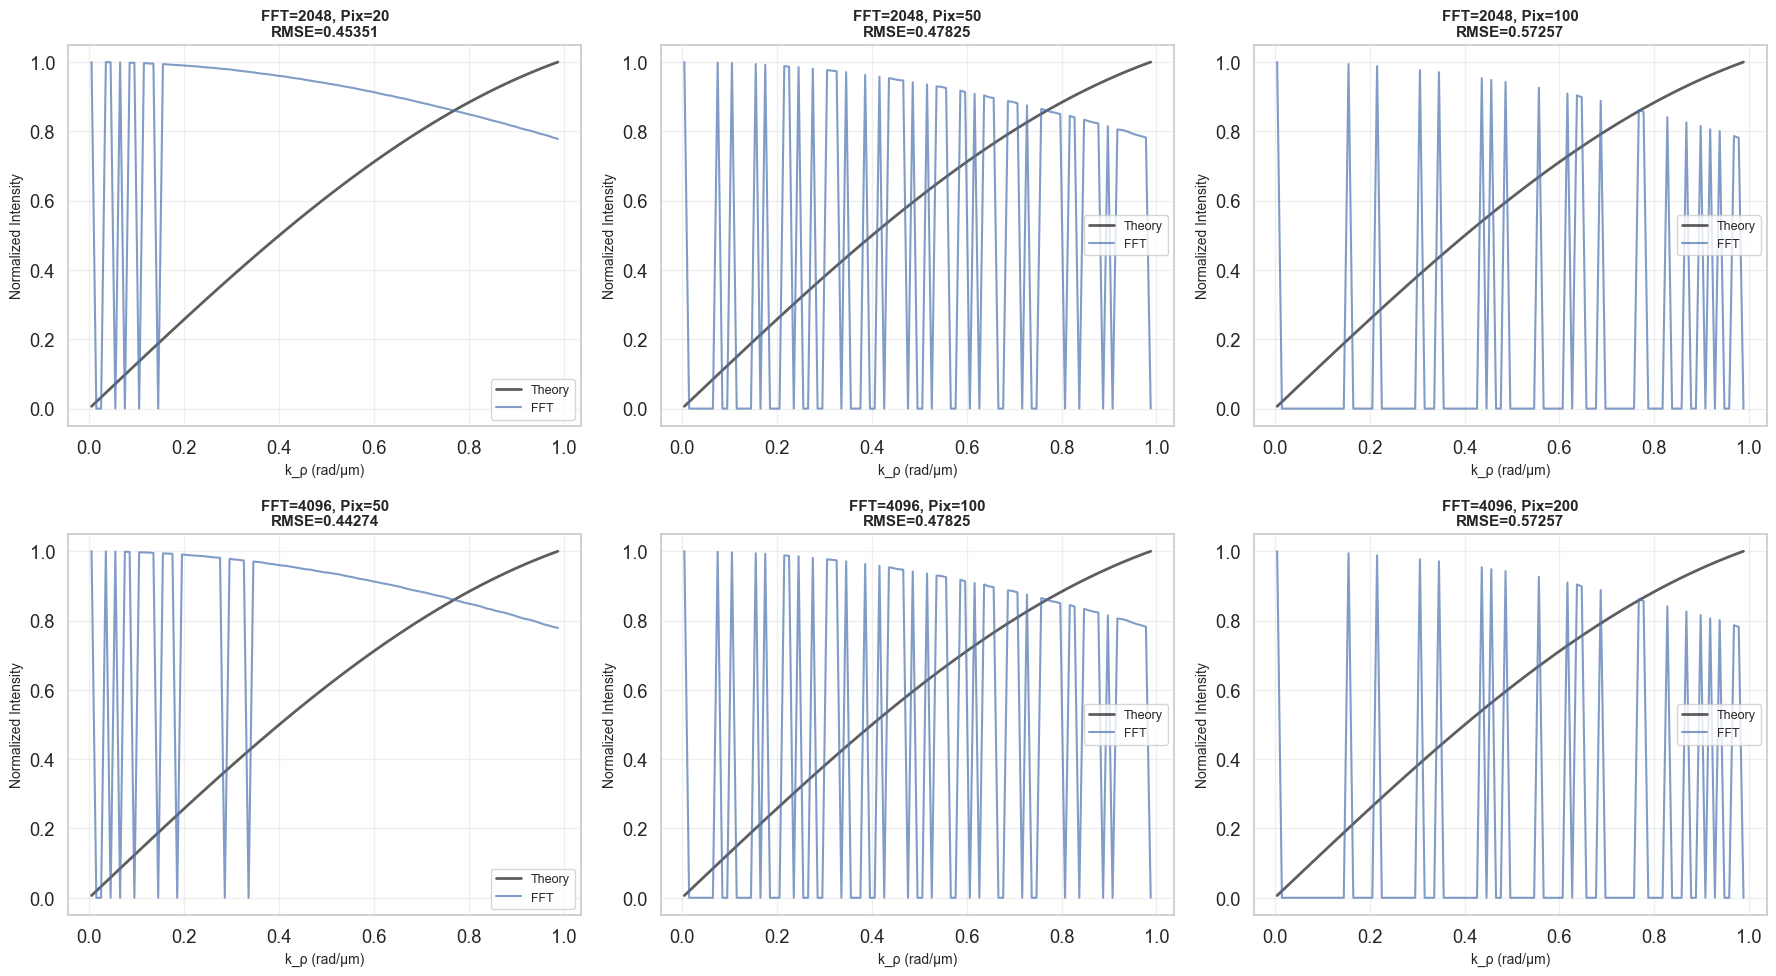

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (fft_sz, pix_target, result) in enumerate(results):
    ax = axes[idx]
    ax.plot(result['k_centers'], result['dist_theory'], 'k-', linewidth=2, 
            label='Theory', alpha=0.7)
    ax.plot(result['k_centers'], result['k_hist'], 'b-', linewidth=1.5, 
            label='FFT', alpha=0.7)
    ax.set_xlabel('k_ρ (rad/μm)', fontsize=10)
    ax.set_ylabel('Normalized Intensity', fontsize=10)
    ax.set_title(f'FFT={fft_sz}, Pix={pix_target}\nRMSE={result["k_rmse"]:.5f}', 
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/fft_grid_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary & Recommendation

In [6]:
print("\n" + "="*70)
print("FFT GRID OPTIMIZATION SUMMARY")
print("="*70)
print("\nCURRENT (FFT=2048, ~20 pixels):")
print(f"  K-space RMSE: {results[0][2]['k_rmse']:.6f}")
print("\nBEST (FFT={}, {} pixels):".format(best_fft, int(best_pix)))
print(f"  K-space RMSE: {best_result['k_rmse']:.6f}")
print(f"  Improvement: {results[0][2]['k_rmse']/best_result['k_rmse']:.1f}x better")
print("\nRECOMMENDATION:")
if best_result['k_rmse'] < 0.05:
    print(f"  ✓ Use FFT size {best_fft} with ~{int(best_pix)} pixels across aperture")
    print(f"  This should significantly smooth the k-space distribution")
else:
    print(f"  Even best config has K-RMSE = {best_result['k_rmse']:.3f}")
    print(f"  FFT discretization may be fundamental limitation")
print("="*70)


FFT GRID OPTIMIZATION SUMMARY

CURRENT (FFT=2048, ~20 pixels):
  K-space RMSE: 0.453509

BEST (FFT=4096, 50 pixels):
  K-space RMSE: 0.442740
  Improvement: 1.0x better

RECOMMENDATION:
  Even best config has K-RMSE = 0.443
  FFT discretization may be fundamental limitation
